# Differentiable imaging with JAX (on the GPU)

`ehtim`'s imaging objective is now backend-agnostic: the same code runs on
NumPy or JAX depending on what array you hand it. That makes the whole
image -> Fourier -> chi-squared + regularizer -> scalar-loss pipeline a single
differentiable, GPU-capable computation graph — so `jax.grad` of the loss is
the imaging gradient, and it matches the hand-written analytic gradient.

This notebook shows:
1. the objective and its **autodiff gradient == the analytic gradient**,
2. the **NFFT** transform differentiated on the **GPU** via `jax-finufft`,
3. an end-to-end reconstruction through `make_image(use_jax=True)`.

**Scope:** this is *image-only* inference (the unknown is the image). The next
step — jointly solving image + gains + D-terms on the *same* `value_and_grad` —
is what the functional rewrite is for, but it needs the Jones forward model +
cal-table redesign that are still in progress.

## Installation

You need **JAX** (GPU build). The `nfft` transform additionally needs
**jax-finufft** (GPU build); the `direct` DFT path needs only JAX.

**JAX (CUDA 12):**
```bash
pip install -U "jax[cuda12]"
```
(this env uses jax 0.10.1 with the pip CUDA-12 plugin.)

**jax-finufft (GPU) — only for `ttype='nfft'`.** The PyPI wheel is CPU-only for
all GPUs, so the GPU NUFFT must be built from source against the JAX you just
installed. On this cluster (system CUDA 12.6, RTX 6000 Ada = `sm_89`):
```bash
pip install "nanobind>=2.9.0" "scikit-build-core>=0.5" ninja setuptools_scm
micromamba install -c conda-forge fftw          # CPU half needs FFTW headers

export CUDA_HOME=/usr/local/cuda-12.6 CUDACXX=$CUDA_HOME/bin/nvcc PATH=$CUDA_HOME/bin:$PATH
export SETUPTOOLS_SCM_PRETEND_VERSION=1.3.1
ARCH=$(nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -1 | tr -d .)
export CMAKE_ARGS="-DJAX_FINUFFT_USE_CUDA=ON -DCMAKE_CUDA_ARCHITECTURES=$ARCH \
  -DCUDAToolkit_ROOT=$CUDA_HOME -Dnanobind_DIR=$(python -c 'import nanobind;print(nanobind.cmake_dir())')"
pip install -v --no-build-isolation --no-deps --force-reinstall \
  --no-binary jax-finufft jax-finufft==1.3.1
```
For CPU-only experimentation, `pip install jax-finufft` (the CPU wheel) is
enough — the objective is identical, just slower. `import ehtim` itself never
imports JAX, so installing neither leaves the NumPy path untouched.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)  # ehtim works in double precision
import jax.numpy as jnp

import ehtim as eh

print("jax", jax.__version__, "->", jax.devices())

Welcome to eht-imaging! v 1.4.0 



jax 0.10.1 -> [CudaDevice(id=0)]


## A synthetic observation

A 1 Jy Gaussian source observed with the EHT 2017 array. Nothing here is
JAX-specific — it is the ordinary `ehtim` simulation path.

In [2]:
src = eh.image.make_empty(32, 200 * eh.RADPERUAS, 17.761, -29.0, rf=230e9)
src = src.add_gauss(1.0, (50 * eh.RADPERUAS, 50 * eh.RADPERUAS, 0, 0, 0))

# arrays/ lives at the repo root; resolve it whether run from tutorials/ or the root
_candidates = ["../arrays/EHT2017.txt", "arrays/EHT2017.txt",
               os.path.join(os.path.dirname(eh.__file__), "..", "arrays", "EHT2017.txt")]
eht = eh.array.load_txt(next(p for p in _candidates if os.path.exists(p)))

np.random.seed(42)  # reproducible thermal noise
obs = src.observe(eht, 5, 600, 0, 24, 4e9, ampcal=True, phasecal=True,
                  ttype="direct", add_th_noise=True)

# a deliberately blurry starting guess (not the truth)
prior = src.blur_circ(40 * eh.RADPERUAS)

DATA_TERM = {"amp": 100, "cphase": 100, "logcamp": 50}
REG_TERM = {"simple": 1, "tv": 10}
# total-variation has a sqrt that is singular where the image is locally flat;
# epsilon_tv regularizes it (a tiny value is plenty) so the gradient stays finite.
EPSILON_TV = 1e-10

Generating empty observation file . . . 


/nfs/horai.dgpsrv/year/rdahale/jax-ehtim/eht-imaging/ehtim/io/load.py:823: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  tdata = np.loadtxt(filename, dtype=bytes, comments='#').astype(str)


Producing clean visibilities from image with direct FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
Adding thermal noise to data . . . 


## The objective and its gradient

`Imager.objfunc(x)` is the scalar imaging loss as a function of the solver
vector `x` (the log-image on the solved pixels). It is written
backend-agnostically, so:

- `imgr.objfunc(x)` / `imgr.objgrad(x)` -> NumPy value / **analytic** gradient,
- `jax.grad(imgr.objfunc)(x)` -> the **autodiff** gradient of the *same* loss.

The whole point: these two gradients agree to machine precision.

In [3]:
imgr = eh.imager.Imager(obs, prior, prior_im=prior, flux=src.total_flux(),
                        data_term=DATA_TERM, reg_term=REG_TERM, epsilon_tv=EPSILON_TV,
                        ttype="direct", pol="I", maxit=100)
imgr.init_imager()
x0 = np.asarray(imgr._init_vec, dtype=np.float64)

loss = float(imgr.objfunc(x0))
grad_analytic = np.asarray(imgr.objgrad(x0))
grad_autodiff = np.asarray(jax.grad(imgr.objfunc)(jnp.asarray(x0)))

rel = np.linalg.norm(grad_autodiff - grad_analytic) / np.linalg.norm(grad_analytic)
print(f"loss = {loss:.6f}")
print(f"gradient device                  : {grad_autodiff.dtype}, "
      f"{jax.grad(imgr.objfunc)(jnp.asarray(x0)).device}")
print(f"relative ||autodiff - analytic|| = {rel:.2e}")

Initializing imager data products . . .


loss = 21493.695335


gradient device                  : float64, cuda:0
relative ||autodiff - analytic|| = 1.92e-09


That `~1e-9` *relative* agreement (the residual is just XLA reordering the
float64 sums) is the gold standard: autodiff through the functional
`unpack -> transform -> forward-model -> chi^2 + regularizers` reproduces the
hand-derived chain rule. Because the loss is just a JAX function you also get
`jax.jit`, `jax.vmap`, and higher-order derivatives for free.

(`jax_enable_x64` above is essential — ehtim works in double precision; without
it JAX silently uses float32 and the gradient only matches to ~1e-3.)

In [4]:
# value_and_grad is what scipy wants; jit compiles it once and reuses the trace.
value_and_grad = jax.jit(jax.value_and_grad(imgr.objfunc))
v, g = value_and_grad(jnp.asarray(x0))
print(f"jit value_and_grad: value={float(v):.6f}, grad shape={g.shape}, device={g.device}")

jit value_and_grad: value=21493.695335, grad shape=(1024,), device=cuda:0


## NFFT, differentiated on the GPU

For `ttype='nfft'` the forward model is a non-uniform FFT. The same
`jax.grad(objfunc)` runs it through `jax-finufft` on the GPU; `jax-finufft`
supplies the VJP (the adjoint NUFFT), so we never hand-write it.

NFFT is an *approximate* transform, so the autodiff gradient matches the
analytic adjoint only to the NUFFT accuracy `eps` (the residual shrinks as you
tighten `eps`); it is not a bug.

In [5]:
obs_nfft = src.observe(eht, 5, 600, 0, 24, 4e9, ampcal=True, phasecal=True,
                       ttype="nfft", add_th_noise=True)
imgr_n = eh.imager.Imager(obs_nfft, prior, prior_im=prior, flux=src.total_flux(),
                          data_term=DATA_TERM, reg_term=REG_TERM, epsilon_tv=EPSILON_TV,
                          ttype="nfft", pol="I", maxit=100, nfft_eps=1e-9)
imgr_n.init_imager()
xn = np.asarray(imgr_n._init_vec, dtype=np.float64)

g_nfft = np.asarray(jax.grad(imgr_n.objfunc)(jnp.asarray(xn)))
ga_nfft = np.asarray(imgr_n.objgrad(xn))
rel_n = np.linalg.norm(g_nfft - ga_nfft) / np.linalg.norm(ga_nfft)
print(f"nfft gradient device                       : "
      f"{jax.grad(imgr_n.objfunc)(jnp.asarray(xn)).device}")
print(f"nfft relative ||autodiff - analytic|| (eps=1e-9): {rel_n:.2e}")

Generating empty observation file . . . 


Producing clean visibilities from image with nfft FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
Adding thermal noise to data . . . 
Initializing imager data products . . .


nfft gradient device                       : cuda:0
nfft relative ||autodiff - analytic|| (eps=1e-9): 1.73e-06


## End-to-end reconstruction on the JAX objective

`make_image(use_jax=True)` runs scipy L-BFGS-B on the JAX objective (gradient by
autodiff, on the GPU). With `use_jax=False` it is the usual NumPy path — same
answer, and the only thing that changes is which backend computes the gradient.

Imager run 1 
Imaging . . .


time: 3.354608 s
J: 33.035571
chi2_amp : 0.99 chi2_cphase : 1.47 chi2_logcamp : 0.65 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 2 
Imaging . . .


time: 3.049870 s
J: 29.715432
chi2_amp : 0.96 chi2_cphase : 1.47 chi2_logcamp : 0.65 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


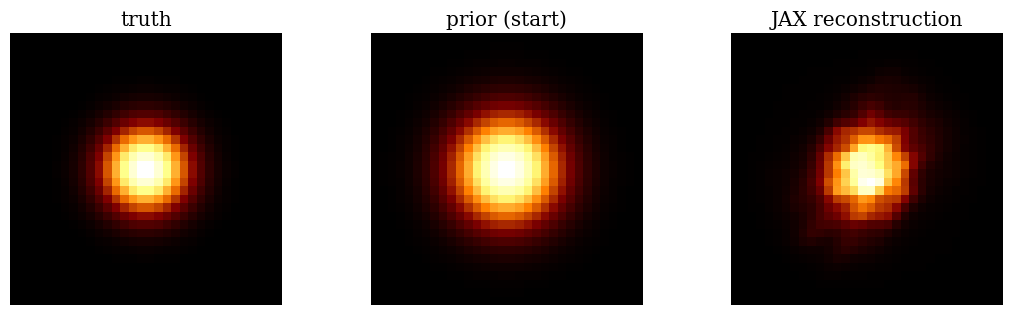

In [6]:
out = imgr.make_image_I(niter=2, use_jax=True, show_updates=False)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, image, title in zip(axes, [src, prior, out],
                            ["truth", "prior (start)", "JAX reconstruction"]):
    ax.imshow(image.imarr(), cmap="afmhot", origin="lower")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## What's next

The unknown here was the image alone. The reason for the functional rewrite is
to swap that single `x` for a pytree `(image, gains, dterms)` and call the
*same* `jax.value_and_grad` — joint calibration + imaging by autodiff, instead
of alternating minimization. That step needs the Jones forward model +
cal-table redesign still in progress; once they land, this objective is the
seam it plugs into.